# Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV # For probability score output
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [ ]:
# Baca file CSV
telecom_df = pd.read_csv('telecom_churn.csv')

In [ ]:
# Muat 5 sampel teratas
telecom_df.head()

,state,account_length,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
0,16,128,415,2845,0,1,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,35,107,415,2301,0,1,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,31,137,415,1616,0,0,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,35,84,408,2510,1,0,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,36,75,415,155,1,0,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [ ]:
# Muat 5 sampel terbawah
telecom_df.tail()

,state,account_length,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
4995,11,50,408,2000,0,1,40,235.7,127,40.07,...,126,18.96,297.5,116,13.39,9.9,5,2.67,2,0
4996,49,152,415,394,0,0,0,184.2,90,31.31,...,73,21.83,213.6,113,9.61,14.7,2,3.97,3,1
4997,7,61,415,313,0,0,0,140.6,89,23.90,...,128,14.69,212.4,97,9.56,13.6,4,3.67,1,0
4998,7,109,510,3471,0,0,0,188.8,67,32.10,...,92,14.59,224.4,89,10.10,8.5,6,2.30,0,0
4999,46,86,415,2412,0,1,34,129.4,102,22.00,...,104,22.70,154.8,100,6.97,9.3,16,2.51,0,0


In [ ]:
# Cek ukuran dataframe
telecom_df.shape

(5000, 21)

In [ ]:
# Tampilkan kolom fitur
telecom_df.columns

Index(['state', 'account_length', 'area_code', 'phone_number',
       'international_plan', 'voice_mail_plan', 'number_vmail_messages',
       'total_day_minutes', 'total_day_calls', 'total_day_charge',
       'total_eve_minutes', 'total_eve_calls', 'total_eve_charge',
       'total_night_minutes', 'total_night_calls', 'total_night_charge',
       'total_intl_minutes', 'total_intl_calls', 'total_intl_charge',
       'number_customer_service_calls', 'class'],
      dtype='object')

In [ ]:
# Dapatkan ringkasan tipe data dari dataframe
telecom_df.dtypes

,0
state,int64
account_length,int64
area_code,int64
phone_number,int64
international_plan,int64
voice_mail_plan,int64
number_vmail_messages,int64
total_day_minutes,float64
total_day_calls,int64
total_day_charge,float64


In [ ]:
telecom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   state                          5000 non-null   int64  
 1   account_length                 5000 non-null   int64  
 2   area_code                      5000 non-null   int64  
 3   phone_number                   5000 non-null   int64  
 4   international_plan             5000 non-null   int64  
 5   voice_mail_plan                5000 non-null   int64  
 6   number_vmail_messages          5000 non-null   int64  
 7   total_day_minutes              5000 non-null   float64
 8   total_day_calls                5000 non-null   int64  
 9   total_day_charge               5000 non-null   float64
 10  total_eve_minutes              5000 non-null   float64
 11  total_eve_calls                5000 non-null   int64  
 12  total_eve_charge               5000 non-null   f

# Data Visualization

<function matplotlib.pyplot.show(close=None, block=None)>

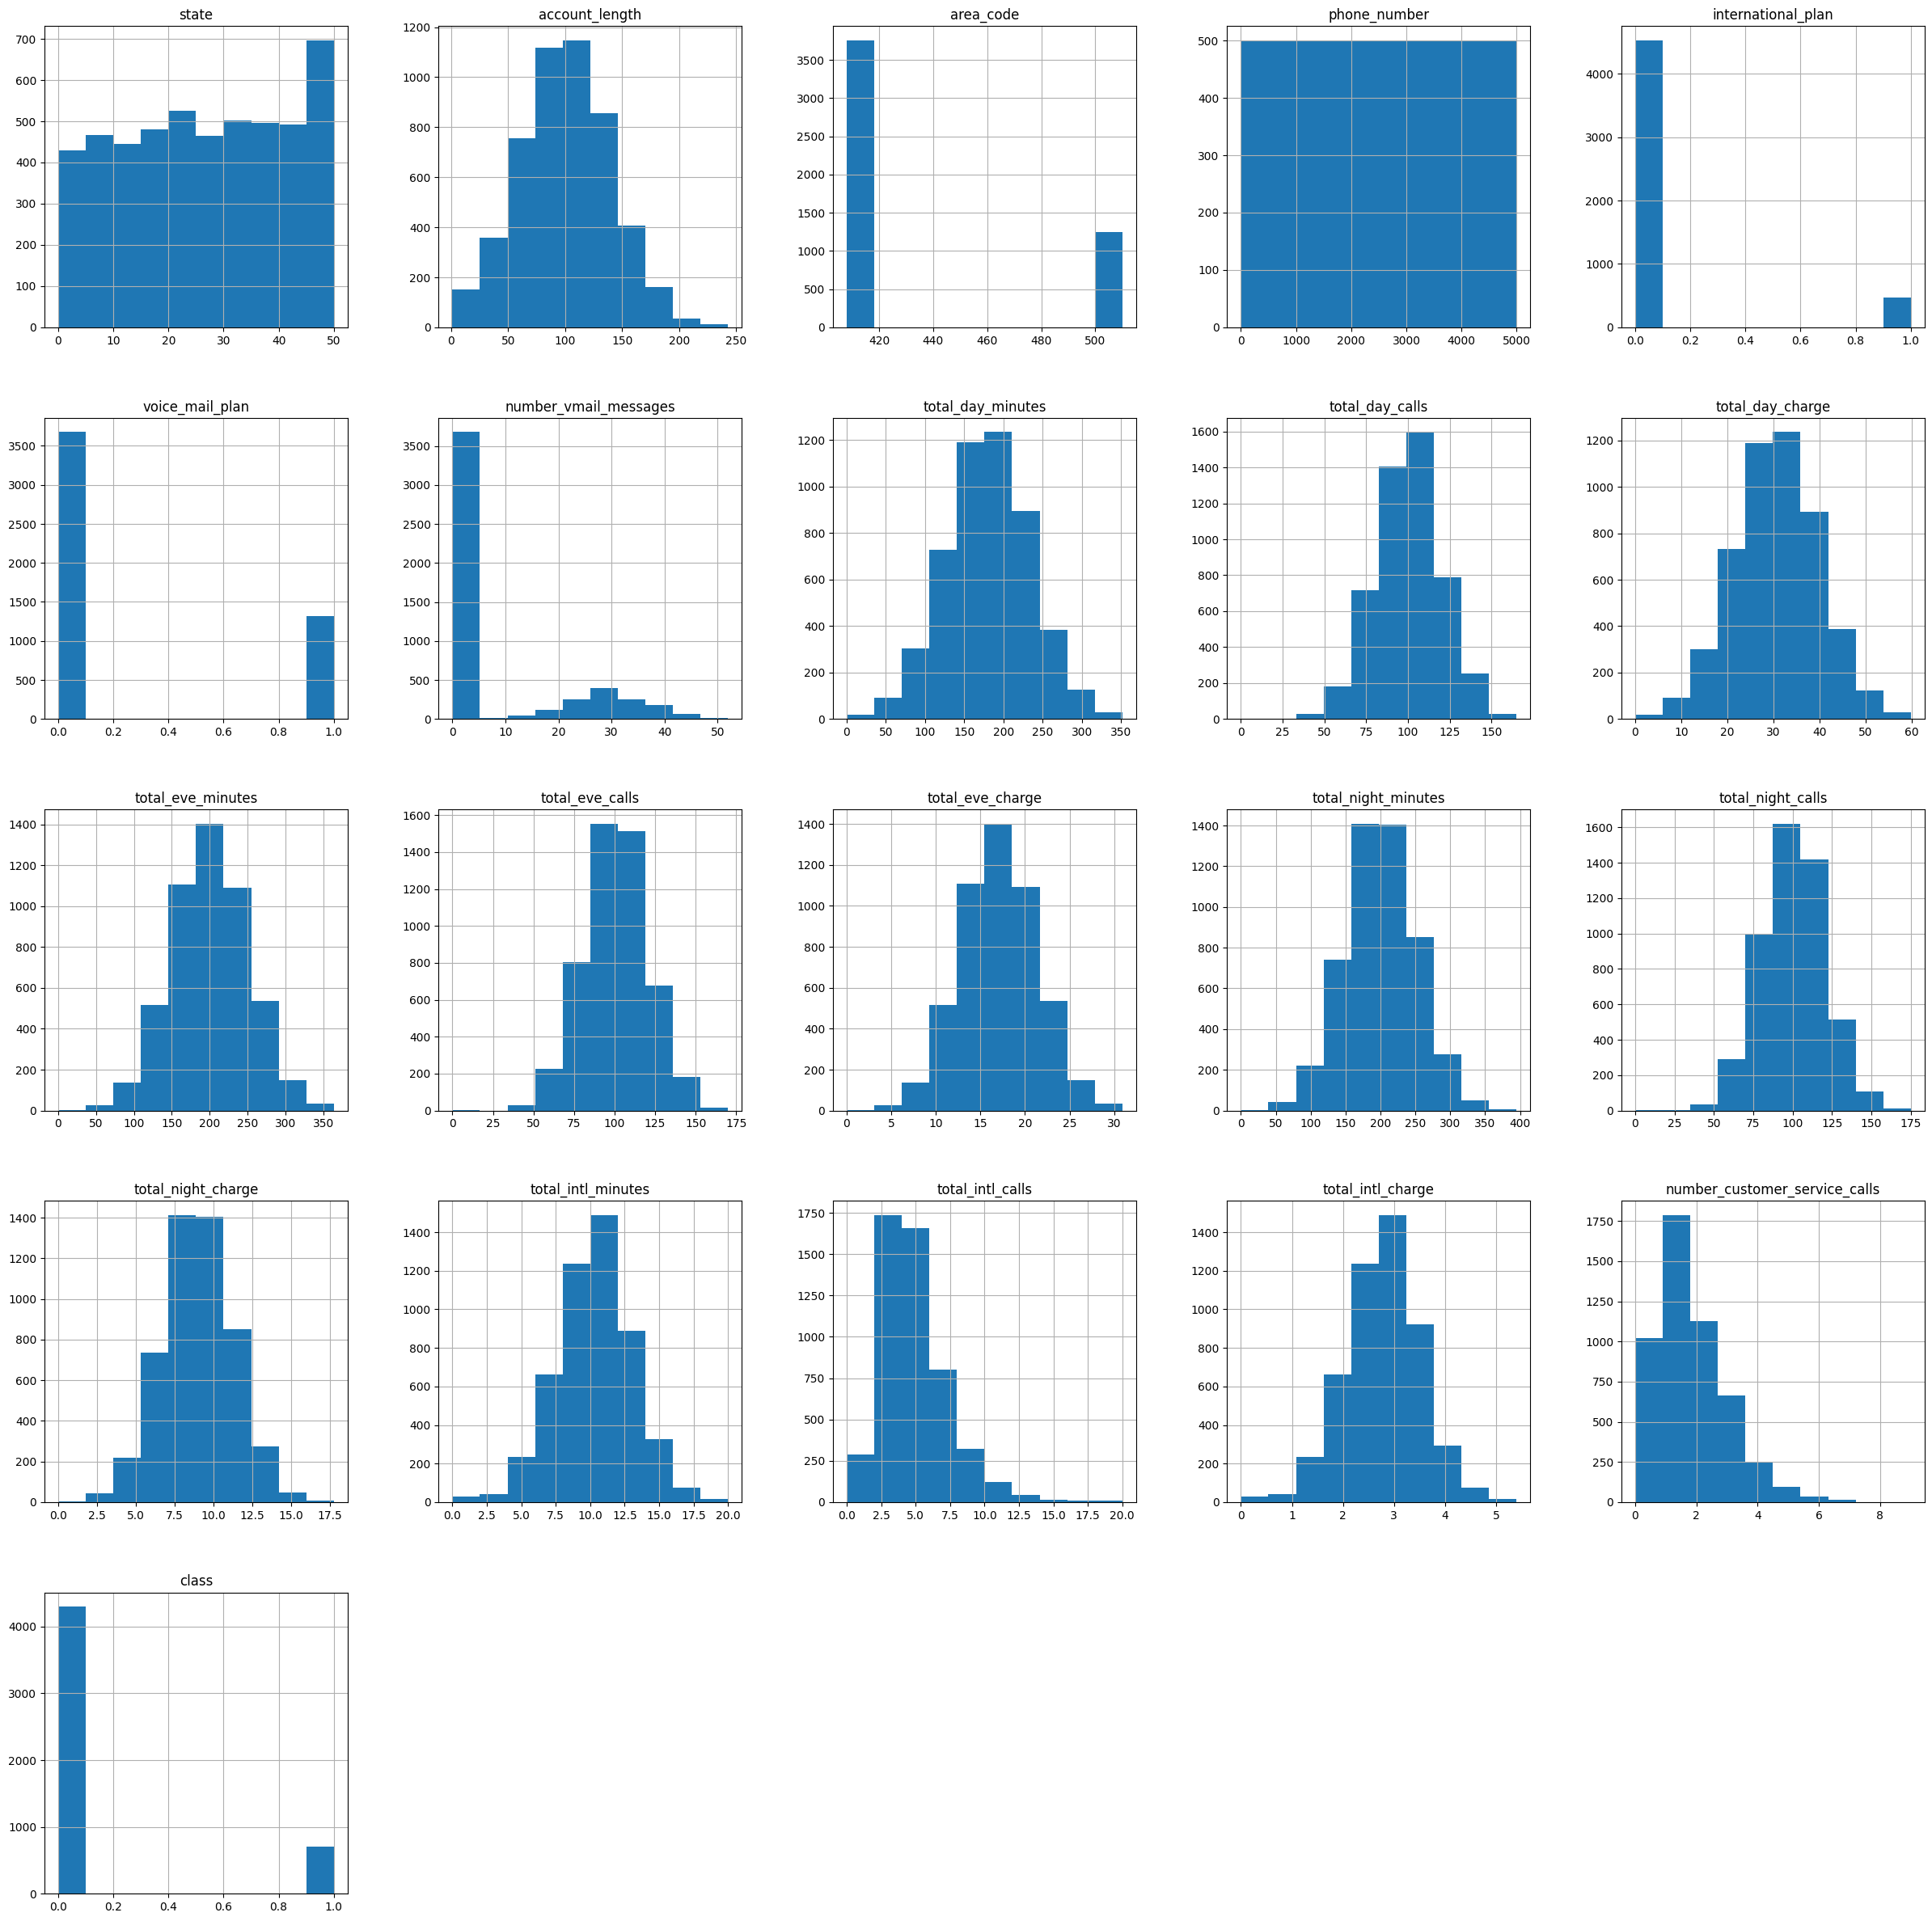

In [ ]:
telecom_df.hist(figsize= (30, 30))
plt.show

In [ ]:
telecom_df['class'].value_counts()

,count
class,
0,4293
1,707


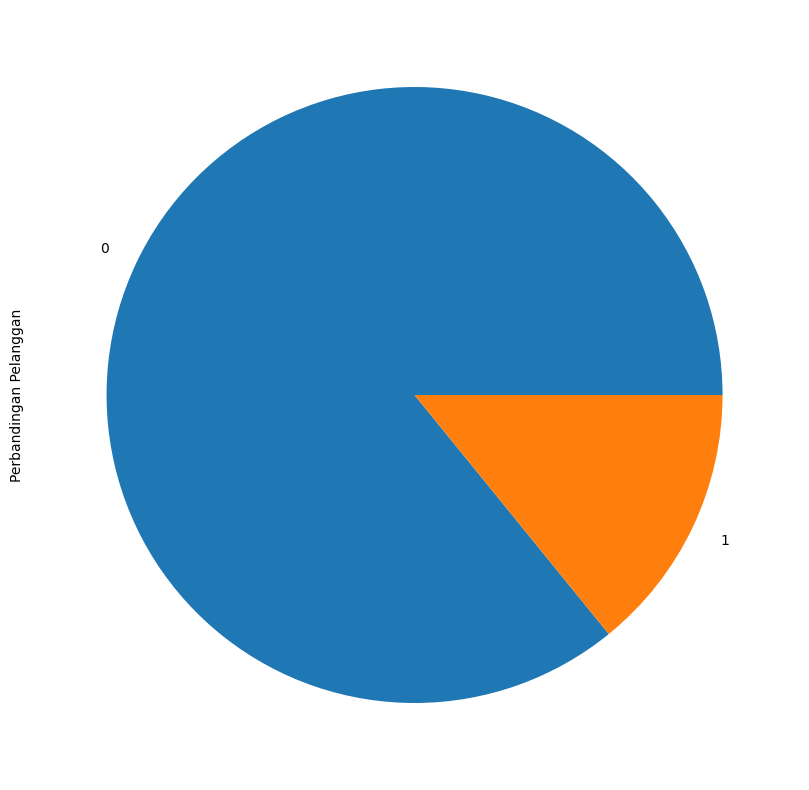

In [ ]:
plt.figure(figsize=(10, 10))
telecom_df['class'].value_counts().plot(kind = 'pie')
plt.ylabel("Perbandingan Pelanggan")
plt.show()

In [ ]:
telecom_df.corr()

,state,account_length,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
state,1.000000,0.010334,0.013858,0.017054,0.007422,-0.030075,-0.027282,0.007334,-0.008166,0.007334,...,-0.005458,0.003896,0.009538,-0.001699,0.009532,-0.009313,0.009898,-0.009322,-0.012997,0.006946
account_length,0.010334,1.000000,-0.018054,0.004918,0.014681,-0.006650,-0.014575,-0.001017,0.028240,-0.001019,...,0.009143,-0.009587,0.000668,-0.007825,0.000656,0.001291,0.014277,0.001292,-0.001445,0.021203
area_code,0.013858,-0.018054,1.000000,-0.011648,0.032107,-0.003006,-0.003399,-0.019118,-0.019314,-0.019119,...,-0.012300,0.007114,0.002084,0.014657,0.002070,-0.004154,-0.013623,-0.004219,0.020921,0.010195
phone_number,0.017054,0.004918,-0.011648,1.000000,0.010463,0.014384,0.010649,0.002420,-0.012911,0.002415,...,0.022450,-0.006805,0.008814,0.012723,0.008806,-0.008109,-0.024928,-0.008056,0.028258,0.012371
international_plan,0.007422,0.014681,0.032107,0.010463,1.000000,0.009054,0.011947,0.028138,0.008102,0.028141,...,0.002505,0.021234,-0.026508,0.005623,-0.026510,0.031799,0.004493,0.031751,-0.012974,0.259123
voice_mail_plan,-0.030075,-0.006650,-0.003006,0.014384,0.009054,1.000000,0.954508,0.002059,-0.001735,0.002056,...,-0.005916,0.023332,0.005524,0.009176,0.005522,0.004116,-0.007525,0.004165,-0.014453,-0.110698
number_vmail_messages,-0.027282,-0.014575,-0.003399,0.010649,0.011947,0.954508,1.000000,0.005381,0.000883,0.005377,...,-0.003954,0.019496,0.005541,0.002676,0.005535,0.002463,0.000124,0.002505,-0.007086,-0.097633
total_day_minutes,0.007334,-0.001017,-0.019118,0.002420,0.028138,0.002059,0.005381,1.000000,0.001935,1.000000,...,0.008128,-0.010760,0.011799,0.004236,0.011783,-0.019486,-0.001303,-0.019415,0.002733,0.207705
total_day_calls,-0.008166,0.028240,-0.019314,-0.012911,0.008102,-0.001735,0.000883,0.001935,1.000000,0.001936,...,0.003754,-0.000695,0.002804,-0.008308,0.002802,0.013097,0.010893,0.013161,-0.010739,0.016130
total_day_charge,0.007334,-0.001019,-0.019119,0.002415,0.028141,0.002056,0.005377,1.000000,0.001936,1.000000,...,0.008129,-0.010757,0.011801,0.004235,0.011785,-0.019490,-0.001307,-0.019419,0.002726,0.207700


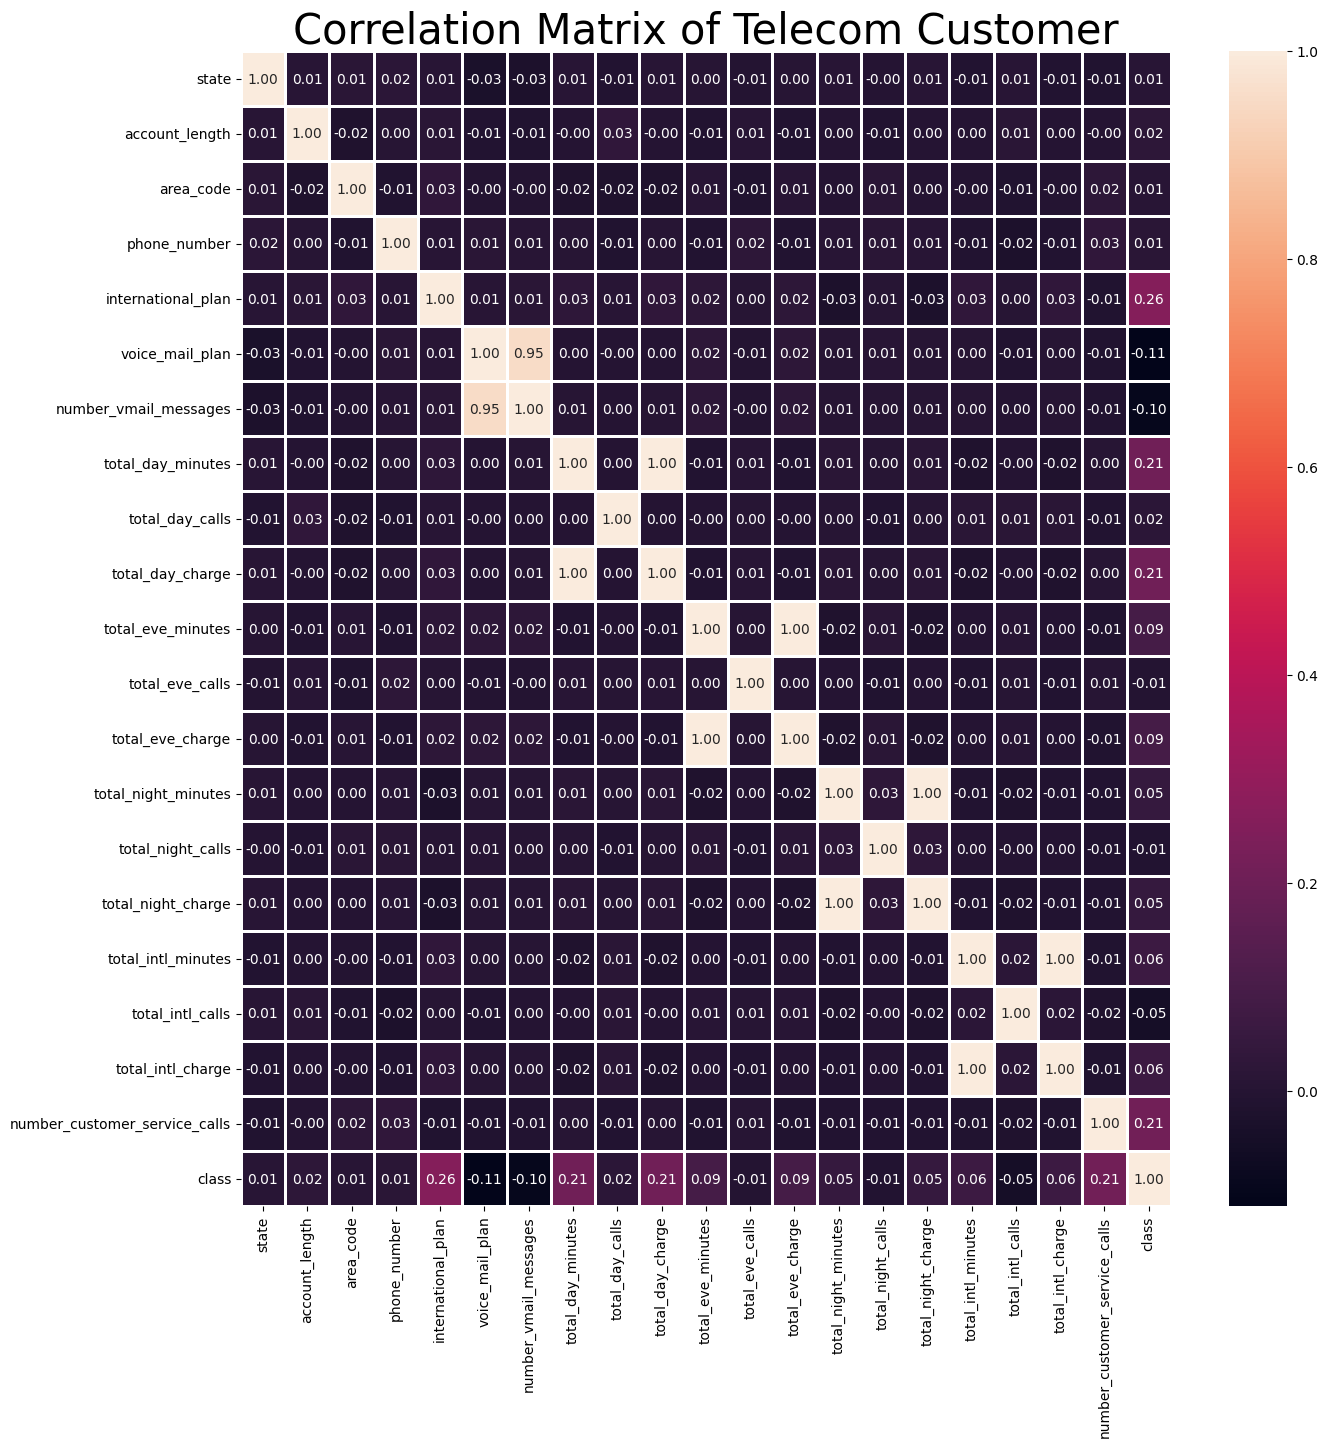

In [ ]:
# Matrix Korelasi
corr_matrix = telecom_df.corr()
plt.figure(figsize= (15, 15))
cm = sns.heatmap(corr_matrix,
                 linewidths = 1,
                 annot = True,
                 fmt = '.2f')
plt.title("Correlation Matrix of Telecom Customer", fontsize = 30)
plt.show()

# Terlihat jelas bahwa "voice_mail_plan" dan "number_vmail_messages" sangat berkorelasi.
# Terlihat jelas bahwa "total biaya hari" dan "total menit harian" sangat berkorelasi.

/tmp/ipython-input-365961069.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(telecom_df.total_day_charge[(telecom_df["class"] == 0)],
/tmp/ipython-input-365961069.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(telecom_df.total_day_charge[(telecom_df["class"] == 1)],


Text(0.5, 1.0, 'Distribution of day charges by churn')

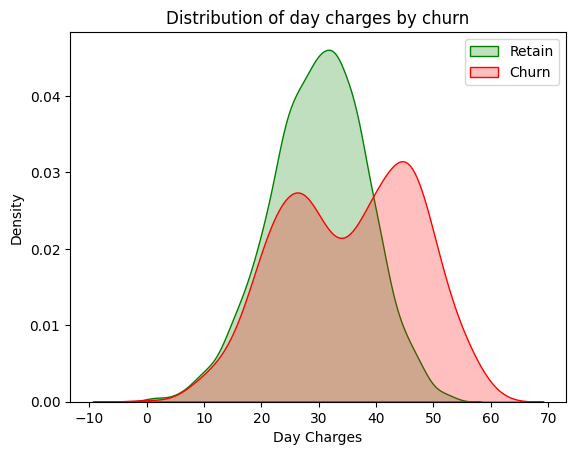

In [ ]:
# Churn berdasarkan day charges
ax = sns.kdeplot(telecom_df.total_day_charge[(telecom_df["class"] == 0)],
                 color = "Green", shade = True)
ax = sns.kdeplot(telecom_df.total_day_charge[(telecom_df["class"] == 1)],
                 color = "Red", shade = True)

ax.legend(["Retain", "Churn"], loc = "upper right")
ax.set_ylabel("Density")
ax.set_xlabel("Day Charges")
ax.set_title("Distribution of day charges by churn")

/tmp/ipython-input-1523877228.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(telecom_df.total_eve_charge[(telecom_df['class'] == 0)],
/tmp/ipython-input-1523877228.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(telecom_df.total_eve_charge[(telecom_df['class'] == 1)],


Text(0.5, 1.0, 'Distribution of Evening charges by churn')

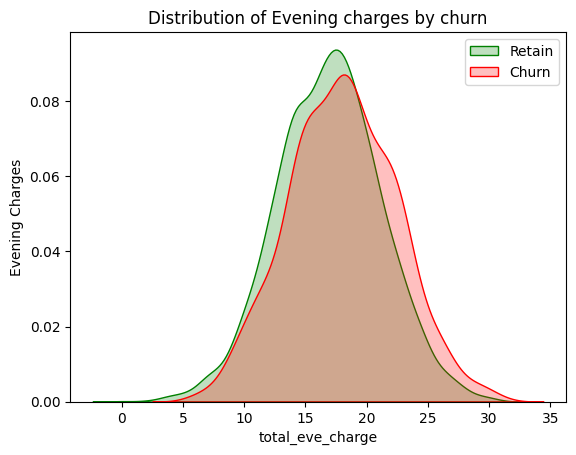

In [ ]:
# Churn berdasarkan Evening charges
ax = sns.kdeplot(telecom_df.total_eve_charge[(telecom_df['class'] == 0)],
                 color = 'Green', shade = True)
ax = sns.kdeplot(telecom_df.total_eve_charge[(telecom_df['class'] == 1)],
                 color = 'Red', shade = True)

ax.legend(['Retain', 'Churn'], loc = 'upper right')
ax.set_ylabel('Density')
ax.set_ylabel('Evening Charges')
ax.set_title("Distribution of Evening charges by churn")

# Data Preprocessing

In [ ]:
# Fitur yang tidak diperlukan akan menurunkan kecepatan pelatihan, interpretasi model, dan kinerja generalisasi pada data uji.
# Oleh karena itu, menemukan dan memilih fitur yang paling berguna dalam kumpulan data sangatlah penting.
# Menetapkan fitur input ke X dan output (Churn) ke y

X = telecom_df.drop(["class", "area_code", "phone_number"], axis = "columns") # area_code and phone_number features are irrelevant to proceed further to train the model
y = telecom_df["class"]

In [ ]:
X.shape

(5000, 18)

In [ ]:
y.shape

(5000,)

## Data Splitting

In [ ]:
# Lakukan pembagian data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 150)

In [ ]:
X_train.shape

(3500, 18)

In [ ]:
X_test.shape

(1500, 18)

## Feature Importance

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train.values.ravel())

RandomForestClassifier()

In [ ]:
rf.feature_importances_

array([0.02412808, 0.02893467, 0.07540969, 0.02252403, 0.02696664,
       0.15313947, 0.02659166, 0.14231048, 0.06640864, 0.02409766,
       0.05980048, 0.03772614, 0.02922608, 0.03870993, 0.03910075,
       0.05101107, 0.04119933, 0.11271519])

In [ ]:
X.columns

Index(['state', 'account_length', 'international_plan', 'voice_mail_plan',
       'number_vmail_messages', 'total_day_minutes', 'total_day_calls',
       'total_day_charge', 'total_eve_minutes', 'total_eve_calls',
       'total_eve_charge', 'total_night_minutes', 'total_night_calls',
       'total_night_charge', 'total_intl_minutes', 'total_intl_calls',
       'total_intl_charge', 'number_customer_service_calls'],
      dtype='object')

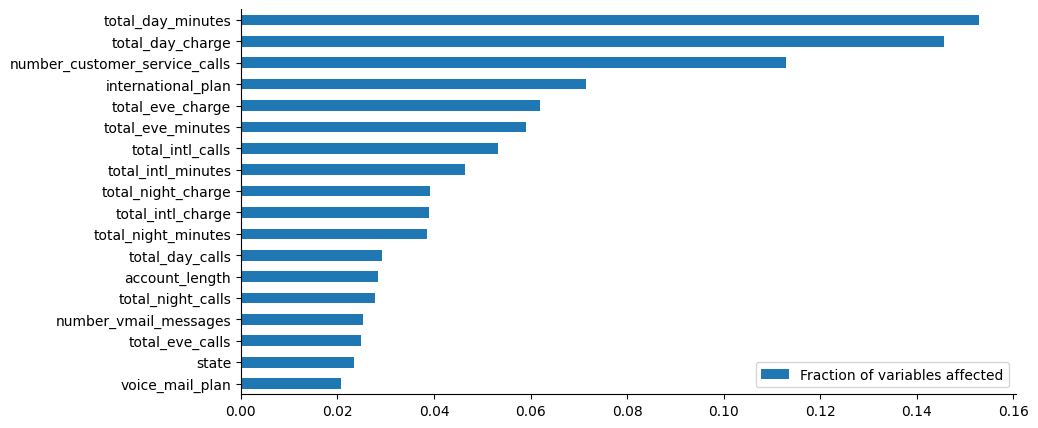

In [ ]:
# Plot feature importance

feat_scores= pd.DataFrame({"Fraction of variables affected" : rf.feature_importances_},index = X.columns)
feat_scores= feat_scores.sort_values(by = "Fraction of variables affected")
feat_scores.plot(kind = "barh", figsize = (10, 5))
sns.despine()

# Training & Evaluate

## Logistic Regression

In [ ]:
model_LR = LogisticRegression()

model_LR.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_predict = model_LR.predict(X_test)

In [ ]:
y_predict

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
print(classification_report(y_test, y_predict))
# precision adalah rasio TP/(TP+FP)
# recall adalah rasio TP/(TP+FN)
# Skor F-beta dapat diartikan sebagai rata-rata harmonik tertimbang dari precision dan recall
# di mana skor F-beta mencapai nilai terbaiknya pada 1 dan skor terburuk pada 0.


              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1299
           1       0.40      0.09      0.15       201

    accuracy                           0.86      1500
   macro avg       0.64      0.54      0.54      1500
weighted avg       0.81      0.86      0.82      1500



**PELUANG PRAKTEK #3 [OPSIONAL]:**
- **Cetak confusion matrix dan komentari hasilnya**


In [ ]:
cm = confusion_matrix(y_test, y_predict)
cm

array([[1271,   28],
       [ 182,   19]])

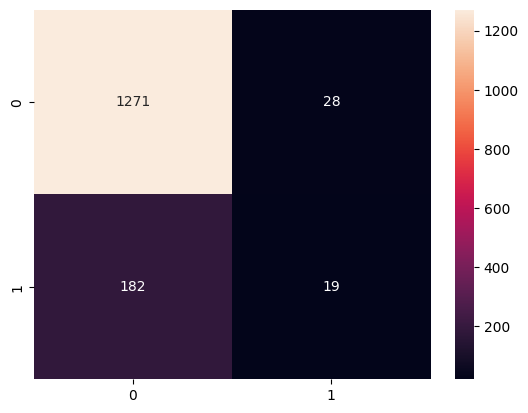

In [ ]:
sns.heatmap(cm, annot = True, fmt = 'd');

## SVM

In [ ]:
model_svc = LinearSVC(max_iter=100000)
model_svm = CalibratedClassifierCV(model_svc)
model_svm.fit(X_train, y_train)

CalibratedClassifierCV(estimator=LinearSVC(max_iter=100000))

In [ ]:
y_predict = model_svm.predict(X_test)

In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1299
           1       0.47      0.18      0.27       201

    accuracy                           0.86      1500
   macro avg       0.68      0.58      0.59      1500
weighted avg       0.83      0.86      0.84      1500



<Axes: >

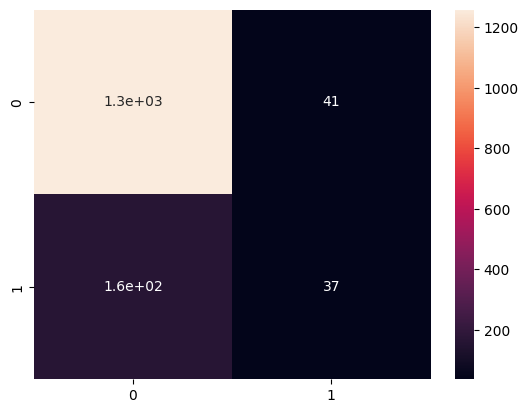

In [ ]:
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, annot = True)

## RF Classifier

In [ ]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_predict = model_rf.predict(X_test)

In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1299
           1       0.92      0.75      0.83       201

    accuracy                           0.96      1500
   macro avg       0.94      0.87      0.90      1500
weighted avg       0.96      0.96      0.96      1500



<Axes: >

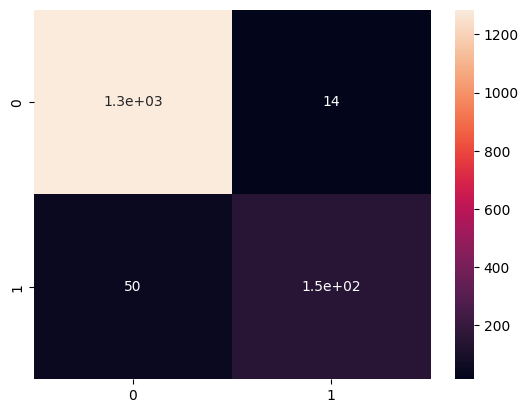

In [ ]:
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, annot = True)

## KNN

In [ ]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_predict = model_knn.predict(X_test)

In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.89      0.98      0.94      1299
           1       0.67      0.25      0.37       201

    accuracy                           0.88      1500
   macro avg       0.78      0.62      0.65      1500
weighted avg       0.86      0.88      0.86      1500



<Axes: >

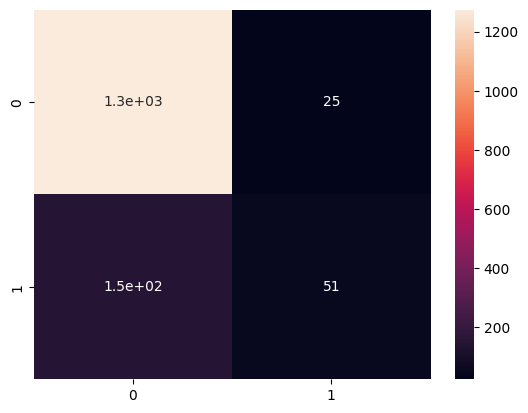

In [ ]:
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, annot = True)

**PELUANG PRAKTEK #4 [OPSIONAL]:**
- **Manakah dari jawaban berikut yang menunjukkan jarak Euclidean antara dua titik A(1, 3) dan B(2, 3)?**

1. 2
2. 4
3. 1
4. 8

In [ ]:
x1,y1,x2,y2 = 1,3,2,3

def euclid_dist(x1,y1,x2,y2):
  return np.sqrt((x2-x1)**2 + (y2-y1)**2)**(0.5)

euclid_dist(x1,y1,x2,y2)

np.float64(1.0)

## Naive Bayes

In [ ]:
model_gnb = GaussianNB()
model_gnb.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_predict = model_gnb.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1299
           1       0.53      0.52      0.52       201

    accuracy                           0.87      1500
   macro avg       0.73      0.72      0.72      1500
weighted avg       0.87      0.87      0.87      1500



<Axes: >

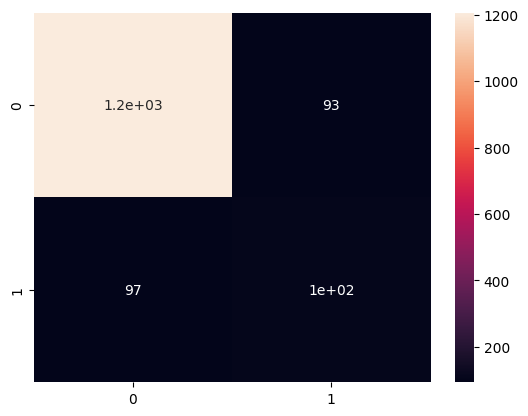

In [ ]:
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, annot = True)

# ROC Curve

In [ ]:
model_LR.predict_proba(X_test)
# Elemen pertama adalah probabilitas bahwa keluaran akan menjadi 0
# Elemen kedua adalah probabilitas bahwa keluaran akan menjadi 1

array([[0.97583743, 0.02416257],
       [0.9246918 , 0.0753082 ],
       [0.90607976, 0.09392024],
       ...,
       [0.92540569, 0.07459431],
       [0.95262859, 0.04737141],
       [0.97606097, 0.02393903]])

In [ ]:
model_LR.predict_proba(X_test)[:, 1]

array([0.02416257, 0.0753082 , 0.09392024, ..., 0.07459431, 0.04737141,
       0.02393903])

In [ ]:
y_test

,class
4827,0
1793,0
2957,0
4218,0
2188,0
...,...
4230,1
3824,0
262,0
1100,0


In [ ]:
fpr1, tpr1, thresh1 = metrics.roc_curve(y_test, model_LR.predict_proba(X_test)[:, 1], pos_label= 1)

In [ ]:
fpr1

array([0.00000000e+00, 7.69822941e-04, 7.69822941e-04, 1.53964588e-03,
       1.53964588e-03, 2.30946882e-03, 2.30946882e-03, 3.07929176e-03,
       3.07929176e-03, 6.15858353e-03, 6.15858353e-03, 8.46805235e-03,
       8.46805235e-03, 1.00076982e-02, 1.00076982e-02, 1.15473441e-02,
       1.15473441e-02, 1.46266359e-02, 1.46266359e-02, 1.53964588e-02,
       1.53964588e-02, 1.61662818e-02, 1.61662818e-02, 1.69361047e-02,
       1.69361047e-02, 1.84757506e-02, 1.84757506e-02, 2.46343341e-02,
       2.46343341e-02, 2.54041570e-02, 2.54041570e-02, 2.77136259e-02,
       2.77136259e-02, 3.61816782e-02, 3.61816782e-02, 4.08006159e-02,
       4.08006159e-02, 4.15704388e-02, 4.15704388e-02, 4.23402617e-02,
       4.23402617e-02, 4.31100847e-02, 4.31100847e-02, 4.38799076e-02,
       4.38799076e-02, 4.69591994e-02, 4.69591994e-02, 4.77290223e-02,
       4.77290223e-02, 4.84988453e-02, 4.84988453e-02, 5.31177829e-02,
       5.31177829e-02, 5.69668976e-02, 5.69668976e-02, 5.77367206e-02,
      

In [ ]:
tpr1

array([0.        , 0.        , 0.00497512, 0.00497512, 0.00995025,
       0.00995025, 0.01492537, 0.01492537, 0.0199005 , 0.0199005 ,
       0.02487562, 0.02487562, 0.03482587, 0.03482587, 0.039801  ,
       0.039801  , 0.04477612, 0.04477612, 0.04975124, 0.04975124,
       0.06467662, 0.06467662, 0.07462687, 0.07462687, 0.08457711,
       0.08457711, 0.09452736, 0.09452736, 0.11442786, 0.11442786,
       0.11940299, 0.11940299, 0.12437811, 0.12437811, 0.12935323,
       0.12935323, 0.15422886, 0.15422886, 0.15920398, 0.15920398,
       0.1641791 , 0.1641791 , 0.16915423, 0.16915423, 0.17412935,
       0.17412935, 0.1840796 , 0.1840796 , 0.18905473, 0.18905473,
       0.20895522, 0.20895522, 0.21393035, 0.21393035, 0.21890547,
       0.21890547, 0.2238806 , 0.2238806 , 0.22885572, 0.22885572,
       0.23383085, 0.23383085, 0.24378109, 0.24378109, 0.24875622,
       0.24875622, 0.25373134, 0.25373134, 0.25870647, 0.25870647,
       0.26368159, 0.26368159, 0.26865672, 0.26865672, 0.27363

In [ ]:
thresh1

array([       inf, 0.86041359, 0.83958458, 0.81006789, 0.77672121,
       0.77278586, 0.76933916, 0.75674736, 0.74855771, 0.7089135 ,
       0.70194553, 0.66022026, 0.65719395, 0.65108045, 0.64984364,
       0.61089044, 0.604749  , 0.56622358, 0.55861961, 0.55629691,
       0.54645562, 0.54631205, 0.54312268, 0.5421339 , 0.52805405,
       0.52633939, 0.51852943, 0.49320741, 0.48128953, 0.48108178,
       0.47377518, 0.46776187, 0.46473692, 0.43854517, 0.43445829,
       0.41737666, 0.41260953, 0.41132929, 0.40986698, 0.40975376,
       0.40838564, 0.40501405, 0.40423163, 0.40255149, 0.40120425,
       0.39599906, 0.39130147, 0.38996657, 0.38609993, 0.38570892,
       0.37555736, 0.36767989, 0.36620282, 0.36407348, 0.36360936,
       0.36322489, 0.36287143, 0.36210651, 0.3619115 , 0.35842803,
       0.35778407, 0.35630691, 0.3537363 , 0.35142502, 0.35123894,
       0.35070135, 0.35020338, 0.34883299, 0.34746946, 0.33974326,
       0.33862345, 0.33481218, 0.33341544, 0.33181122, 0.33131

In [ ]:
# Kurva ROC
from sklearn.metrics import roc_curve

fpr1, tpr1, thresh1 = roc_curve(y_test, model_LR.predict_proba(X_test)[:, 1], pos_label = 1)
fpr2, tpr2, thresh2 = roc_curve(y_test, model_svm.predict_proba(X_test)[:, 1], pos_label = 1)
fpr3, tpr3, thresh3 = roc_curve(y_test, model_rf.predict_proba(X_test)[:, 1], pos_label = 1)
fpr4, tpr4, thresh4 = roc_curve(y_test, model_knn.predict_proba(X_test)[:, 1], pos_label = 1)
fpr5, tpr5, thresh5 = roc_curve(y_test, model_gnb.predict_proba(X_test)[:, 1], pos_label = 1)


In [ ]:
# AUC

from sklearn.metrics import roc_auc_score

auc_score1 = roc_auc_score(y_test, model_LR.predict_proba(X_test)[:, 1])
auc_score2 = roc_auc_score(y_test, model_svm.predict_proba(X_test)[:, 1])
auc_score3 = roc_auc_score(y_test, model_rf.predict_proba(X_test)[:, 1])
auc_score4 = roc_auc_score(y_test, model_knn.predict_proba(X_test)[:, 1])
auc_score5 = roc_auc_score(y_test, model_gnb.predict_proba(X_test)[:, 1])

print("Logistic Regression: ", auc_score1) # Logistic Regression
print("Support Vector Machine: ", auc_score2) # Support Vector Machine
print("Random Forest: ", auc_score3) # Random Forest
print("K-Nearest Neighbors: ", auc_score4) # K-Nearest Neighbors
print("Naive Bayes: ", auc_score5) # Naive Bayes

Logistic Regression:  0.697735341766916
Support Vector Machine:  0.7988310947188615
Random Forest:  0.9115584510090042
K-Nearest Neighbors:  0.6563123566156898
Naive Bayes:  0.8270158062650564


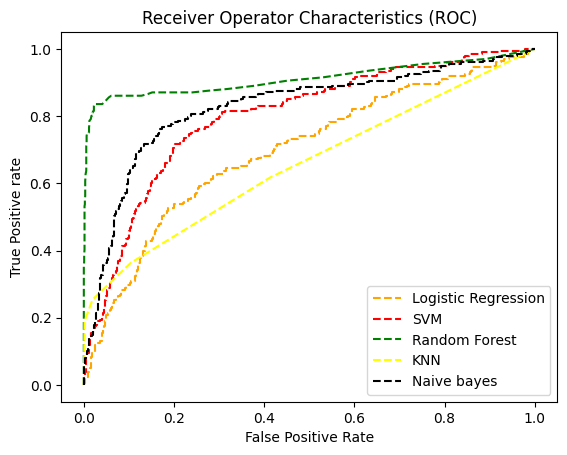

In [ ]:
plt.plot(fpr1, tpr1, linestyle = "--", color = "orange", label = "Logistic Regression")
plt.plot(fpr2, tpr2, linestyle = "--", color = "red", label = "SVM")
plt.plot(fpr3, tpr3, linestyle = "--", color = "green", label = "Random Forest")
plt.plot(fpr4, tpr4, linestyle = "--", color = "yellow", label = "KNN")
plt.plot(fpr5, tpr5, linestyle = "--", color = "black", label = "Naive bayes")

plt.title('Receiver Operator Characteristics (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')

plt.legend(loc = 'best')
plt.savefig('ROC', dpi = 300)
plt.show()

Grafik tersebut menunjukkan bahwa algoritma Random Forest menghasilkan AUC terbaik. Oleh karena itu, jelas bahwa model Random Forest melakukan pekerjaan yang lebih baik dalam mengklasifikasikan pelanggan telekomunikasi yang churn/retain.

# Conclusion

In [ ]:
y_predict = model_rf.predict(X_test)
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1299
           1       0.92      0.75      0.83       201

    accuracy                           0.96      1500
   macro avg       0.94      0.87      0.90      1500
weighted avg       0.96      0.96      0.96      1500



Di antara semua model yang dilatih, algoritma Random Forest Classifier menghasilkan Area tertinggi di bawah kurva ROC (AUC).

Skor berikut adalah hasil dari model Random Forest Classifier

1. Akurasi: ~96%
2. Precision: ~96% dilabeli sebagai Pelanggan yang retain dan ~93% dilabeli sebagai pelanggan churn
3. Recall: ~99% dilabeli sebagai Pelanggan yang retain dan ~76% dilabeli sebagai pelanggan churn

Catatan: Kita dapat meningkatkan model ini lebih baik lagi dengan menggunakan metode "Grid Search".

Pustaka tambahan untuk Grid Search: https://machinelearningmastery.com/hyperparameter-optimization-with-random-search-and-grid-search/